IMPORTS

In [1]:
import pandas as pd
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Chargement dataset initial

In [2]:
def load_football_data(filename: str = "Euro-Football_2012-2023.csv") -> pd.DataFrame:

    # Chemins et URL
    DATASETS_PATH = Path("datasets")
    CSV_FILE_PATH = DATASETS_PATH / filename # Le chemin local pour le fichier CSV

    # L'URL RAW (Brute) pointant vers le nouveau fichier CSV sur GitHub

    URL_GITHUB_CSV = (
        "https://raw.githubusercontent.com/inesnft/Athlete-Performance-Prediction/main/Euro-Football_2012-2023.csv"
    )

    # 1. Vérification et téléchargement
    if not CSV_FILE_PATH.is_file():
        # Crée le répertoire 'datasets' si nécessaire
        DATASETS_PATH.mkdir(parents=True, exist_ok=True)

        print(f"Téléchargement de {filename} depuis GitHub...")
        # Téléchargement du fichier CSV
        urllib.request.urlretrieve(URL_GITHUB_CSV, CSV_FILE_PATH)
        print("Téléchargement terminé.")

    # 2. Chargement des données CSV
    try:
        # pd.read_csv lit le fichier téléchargé localement
        data_frame = pd.read_csv(CSV_FILE_PATH, sep=';')
        return data_frame
    except Exception as e:
        print(f"Erreur lors de la lecture du fichier CSV : {e}")
        return pd.DataFrame()

football_data = load_football_data()

# Vérification
if not football_data.empty:
    print("DataFrame 'football_data' chargé à partir du CSV.")
football_data.head()

DataFrame 'football_data' chargé à partir du CSV.


,id,Country,League,Div,Season,Date,HomeTeam,AwayTeam,Referee,FTHG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,0,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Arsenal,Sunderland,C Foy,0.0,...,4.0,2.0,12.0,8.0,7.0,0.0,0.0,0.0,0.0,0.0
1,1,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Fulham,Norwich,M Oliver,5.0,...,9.0,2.0,12.0,11.0,6.0,3.0,0.0,0.0,0.0,0.0
2,2,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Newcastle,Tottenham,M Atkinson,2.0,...,4.0,6.0,12.0,8.0,3.0,5.0,2.0,2.0,0.0,0.0
3,3,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,QPR,Swansea,L Probert,0.0,...,11.0,8.0,11.0,14.0,5.0,3.0,2.0,2.0,0.0,0.0
4,4,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Reading,Stoke,K Friend,1.0,...,3.0,3.0,9.0,14.0,4.0,3.0,2.0,4.0,0.0,1.0


In [3]:
football_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66147 entries, 0 to 66146
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        66147 non-null  int64  
 1   Country   66147 non-null  object 
 2   League    66147 non-null  object 
 3   Div       66121 non-null  object 
 4   Season    66147 non-null  object 
 5   Date      66121 non-null  object 
 6   HomeTeam  66121 non-null  object 
 7   AwayTeam  66121 non-null  object 
 8   Referee   13620 non-null  object 
 9   FTHG      66119 non-null  float64
 10  FTAG      66119 non-null  float64
 11  FTR       66119 non-null  object 
 12  HTHG      66030 non-null  float64
 13  HTAG      66030 non-null  float64
 14  HTR       66030 non-null  object 
 15  HS        50116 non-null  float64
 16  AS        50116 non-null  float64
 17  HST       50116 non-null  float64
 18  AST       50116 non-null  float64
 19  HF        48778 non-null  float64
 20  AF        48778 non-null  fl

Plus de 10k matchs en Angleterre, on décide pour l'instant de créer un sous-dataset avec uniquement les matchs anglais permettant de réduire le nombre d'équipes ce qui pourra rendre le modèle meilleur en créant moins de colonnes avec OneHotEncoder.

In [4]:
data_eng=football_data[football_data['Country'] == 'England']
data_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10748 entries, 0 to 66120
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        10748 non-null  int64  
 1   Country   10748 non-null  object 
 2   League    10748 non-null  object 
 3   Div       10746 non-null  object 
 4   Season    10748 non-null  object 
 5   Date      10746 non-null  object 
 6   HomeTeam  10746 non-null  object 
 7   AwayTeam  10746 non-null  object 
 8   Referee   10193 non-null  object 
 9   FTHG      10746 non-null  float64
 10  FTAG      10746 non-null  float64
 11  FTR       10746 non-null  object 
 12  HTHG      10745 non-null  float64
 13  HTAG      10745 non-null  float64
 14  HTR       10745 non-null  object 
 15  HS        10745 non-null  float64
 16  AS        10745 non-null  float64
 17  HST       10745 non-null  float64
 18  AST       10745 non-null  float64
 19  HF        10745 non-null  float64
 20  AF        10745 non-null  float64

On supprime les lignes avec des caractéristiques nulles.

In [5]:
data_eng=data_eng.dropna()
data_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10193 entries, 0 to 66120
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        10193 non-null  int64  
 1   Country   10193 non-null  object 
 2   League    10193 non-null  object 
 3   Div       10193 non-null  object 
 4   Season    10193 non-null  object 
 5   Date      10193 non-null  object 
 6   HomeTeam  10193 non-null  object 
 7   AwayTeam  10193 non-null  object 
 8   Referee   10193 non-null  object 
 9   FTHG      10193 non-null  float64
 10  FTAG      10193 non-null  float64
 11  FTR       10193 non-null  object 
 12  HTHG      10193 non-null  float64
 13  HTAG      10193 non-null  float64
 14  HTR       10193 non-null  object 
 15  HS        10193 non-null  float64
 16  AS        10193 non-null  float64
 17  HST       10193 non-null  float64
 18  AST       10193 non-null  float64
 19  HF        10193 non-null  float64
 20  AF        10193 non-null  float64

In [6]:
nombre_equipes_differentes = pd.concat([data_eng['HomeTeam'], data_eng['AwayTeam']]).nunique()
print(f"Nombre d'équipes différentes en Angleterre : {nombre_equipes_differentes}")

Nombre d'équipes différentes en Angleterre : 57


In [7]:
matchs_par_equipe = pd.concat([data_eng['HomeTeam'], data_eng['AwayTeam']]).value_counts()
matchs_par_equipe_sorted = matchs_par_equipe.sort_values(ascending=True)
matchs_par_equipe_sorted.head(10)

Plymouth               25
Milton Keynes Dons     46
Peterboro              46
Yeovil                 46
Wycombe                46
Doncaster              46
Burton                 92
Coventry              163
Blackpool             184
Charlton              184
Name: count, dtype: int64

Sauvegarde du nouveau dataset

In [8]:
data_eng.to_csv('England_football_data.csv', index=False, sep=';')

Chargement et préparation des données

In [9]:
# Configuration de Seaborn pour les graphiques
sns.set_theme(style="whitegrid")


df = pd.read_csv('England_football_data.csv', sep=';')

# Création de la variable cible : TotalGoals
df['TotalGoals'] = df['FTHG'] + df['FTAG']
print(f"Nombre total de lignes pour l'analyse : {len(df)}")

# Conversion de la date (sera supprimée plus tard, mais bonne pratique)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print(df[['HomeTeam', 'AwayTeam', 'TotalGoals']].head())

Nombre total de lignes pour l'analyse : 10193
    HomeTeam    AwayTeam  TotalGoals
0    Arsenal  Sunderland         0.0
1     Fulham     Norwich         5.0
2  Newcastle   Tottenham         3.0
3        QPR     Swansea         5.0
4    Reading       Stoke         2.0


Visualisations des données

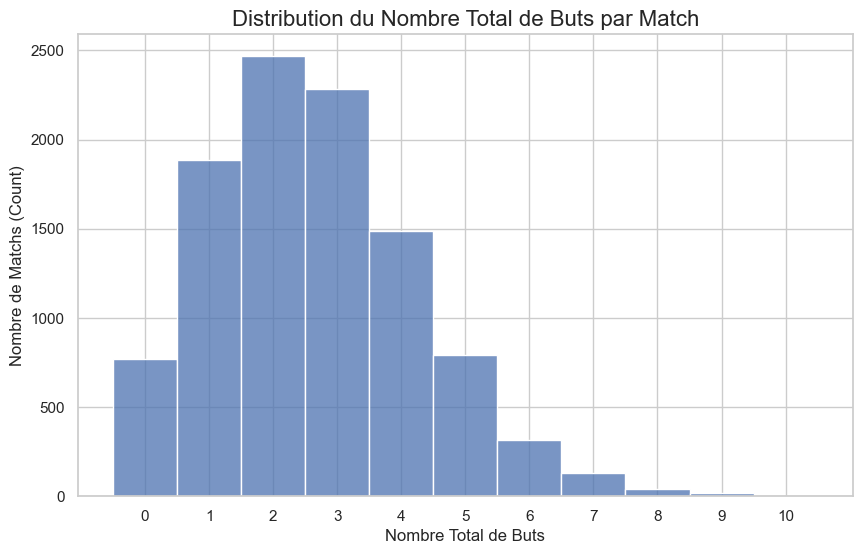

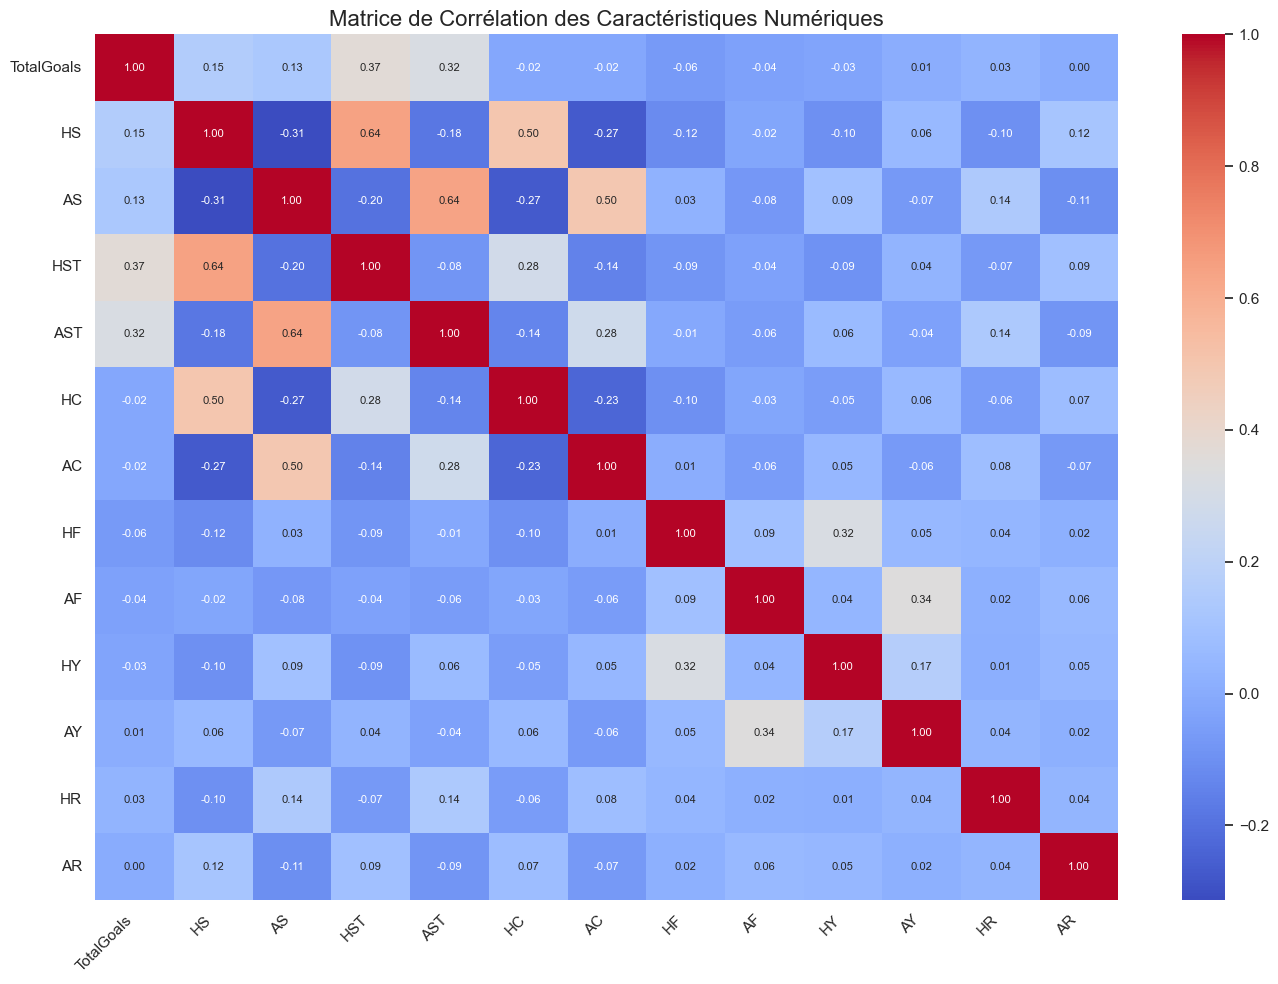

In [10]:
# Visualisation 1 : Distribution de la variable cible (Histogramme seul)
plt.figure(figsize=(10, 6))
max_goals = int(df['TotalGoals'].max())
sns.histplot(df['TotalGoals'], 
             kde=False, 
             bins=range(0, max_goals + 2), # Bins discrets pour les buts
             discrete=True) # Assure que les barres sont centrées sur les entiers

plt.title('Distribution du Nombre Total de Buts par Match', fontsize=16)
plt.xlabel('Nombre Total de Buts', fontsize=12)
plt.ylabel('Nombre de Matchs (Count)', fontsize=12)
plt.xticks(range(0, max_goals + 1, 1))
plt.show()

# Visualisation 2 : Matrice de Corrélation
plt.figure(figsize=(14, 10))
numeric_features_corr = ['TotalGoals', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']
cols_exist = [col for col in numeric_features_corr if col in df.columns]
corr_matrix = df[cols_exist].dropna().corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})
plt.title('Matrice de Corrélation des Caractéristiques Numériques', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Réduction des features (on enlève les features de nombre de buts fin de match et mi-temps sinon la prédiction est trop facile) et séparation données train et test

In [11]:
# Définition de la cible (y) et des features (X)
features_to_drop = [
    'id', 'Date',             
    'FTHG', 'FTAG', 'FTR',    # Fuite de données (Résultats finaux)
    'HTHG', 'HTAG', 'HTR',    # Fuite de données (Résultats mi-temps)
    'TotalGoals'              # Cible
]

X = df.drop(columns=features_to_drop, errors='ignore')
y = df['TotalGoals']

# Identification des types de colonnes
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Caractéristiques numériques ({len(numeric_features)}) : {numeric_features}")
print(f"Caractéristiques catégorielles ({len(categorical_features)}) : {categorical_features}")

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} lignes")

Caractéristiques numériques (12) : ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
Caractéristiques catégorielles (7) : ['Country', 'League', 'Div', 'Season', 'HomeTeam', 'AwayTeam', 'Referee']

Taille de l'ensemble d'entraînement : 8154 lignes
Taille de l'ensemble de test : 2039 lignes


Création pipelines (LinearRegression et RandomForest) avec les données numériques uniquement donc sans prendre en compte les équipes mais uniquement des stats de matchs

In [12]:
# Pipeline pour les données numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Préprocesseur 1 : Numérique seulement (on ignore les autres)
preprocessor_num_only = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop' # Ignorer les colonnes catégorielles
)

# Pipeline 1a : Régression Linéaire (Numérique)
pipeline_lr_num = Pipeline(steps=[
    ('preprocessor', preprocessor_num_only),
    ('model', LinearRegression())
])

# Pipeline 1b : Random Forest (Numérique)
pipeline_rf_num = Pipeline(steps=[
    ('preprocessor', preprocessor_num_only),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

print("Pipelines 'Numérique Uniquement' (LinearRegression, RandomForest) créés.")

Pipelines 'Numérique Uniquement' (LinearRegression, RandomForest) créés.


Entraînement et évaluation simple modèles numérique uniquement

In [13]:
results_list = [] # Liste pour stocker les résultats

# Régression Linéaire
print("Entraînement : Régression Linéaire (Numérique)...")
pipeline_lr_num.fit(X_train, y_train)
y_pred_lr_num = pipeline_lr_num.predict(X_test)
mae_lr_num = mean_absolute_error(y_test, y_pred_lr_num)
r2_lr_num = r2_score(y_test, y_pred_lr_num)
print(f"  -> MAE (LR, Num): {mae_lr_num:.4f} | R2 Score: {r2_lr_num:.4f}")
results_list.append(['Linear Regression', 'Numérique', mae_lr_num, r2_lr_num])

# Random Forest
print("Entraînement : Random Forest (Numérique)...")
pipeline_rf_num.fit(X_train, y_train)
y_pred_rf_num = pipeline_rf_num.predict(X_test)
mae_rf_num = mean_absolute_error(y_test, y_pred_rf_num)
r2_rf_num = r2_score(y_test, y_pred_rf_num)
print(f"  -> MAE (RF, Num): {mae_rf_num:.4f} | R2 Score: {r2_rf_num:.4f}")
results_list.append(['Random Forest', 'Numérique', mae_rf_num, r2_rf_num])

Entraînement : Régression Linéaire (Numérique)...
  -> MAE (LR, Num): 1.0994 | R2 Score: 0.2720
Entraînement : Random Forest (Numérique)...
  -> MAE (RF, Num): 1.0985 | R2 Score: 0.2738


Création pipelines (LinearRegression et RandomForest) avec toutes les données

In [14]:
# Pipeline pour les données catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Préprocesseur 2 : Numérique ET Catégoriel
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Pipeline 2a : Régression Linéaire (Full)
pipeline_lr_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', LinearRegression())
])

# Pipeline 2b : Random Forest (Full)
pipeline_rf_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

print("Pipelines 'Numérique + Catégoriel' (LinearRegression, RandomForest) créés.")

Pipelines 'Numérique + Catégoriel' (LinearRegression, RandomForest) créés.


Entraînement et évaluation simple modèles complets (numérique + catégoriel)

In [15]:
# Régression Linéaire
print("Entraînement : Régression Linéaire (Full)...")
pipeline_lr_full.fit(X_train, y_train)
y_pred_lr_full = pipeline_lr_full.predict(X_test)
mae_lr_full = mean_absolute_error(y_test, y_pred_lr_full)
r2_lr_full = r2_score(y_test, y_pred_lr_full)
print(f"  -> MAE (LR, Full): {mae_lr_full:.4f} | R2 Score: {r2_lr_full:.4f}")
results_list.append(['Linear Regression', 'Num + Catégoriel', mae_lr_full, r2_lr_full])

# Random Forest
print("Entraînement : Random Forest (Full)...")
pipeline_rf_full.fit(X_train, y_train)
y_pred_rf_full = pipeline_rf_full.predict(X_test)
mae_rf_full = mean_absolute_error(y_test, y_pred_rf_full)
r2_rf_full = r2_score(y_test, y_pred_rf_full)
print(f"  -> MAE (RF, Full): {mae_rf_full:.4f} | R2 Score: {r2_rf_full:.4f}")
results_list.append(['Random Forest', 'Num + Catégoriel', mae_rf_full, r2_rf_full])

Entraînement : Régression Linéaire (Full)...
  -> MAE (LR, Full): 14843959.5483 | R2 Score: -57041250021659272.0000
Entraînement : Random Forest (Full)...
  -> MAE (RF, Full): 1.0929 | R2 Score: 0.2859


In [16]:
# Créer un DataFrame pour comparer les résultats
results_df = pd.DataFrame(
    results_list, 
    columns=['Modèle', 'Features', 'MAE', 'R2 Score']
)

# Trier par R2 Score (meilleur en premier)
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print("Tableau comparatif des performances des modèles :")
# L'affichage de 'results_df' dans un notebook sera bien formaté
results_df

Tableau comparatif des performances des modèles :


,Modèle,Features,MAE,R2 Score
3,Random Forest,Num + Catégoriel,1.092905e+00,2.858833e-01
1,Random Forest,Numérique,1.098468e+00,2.738473e-01
0,Linear Regression,Numérique,1.099363e+00,2.719835e-01
2,Linear Regression,Num + Catégoriel,1.484396e+07,-5.704125e+16


Le modèle de régression linéaire est mauvais avec des performances particulièrement mauvaises avec toutes les données. Le meilleur est le RandomForest avec toutes les données.
Mais cela reste très moyen. 
Le premier problème peut être du au fait que la régression linéaire a explosé parce que le OneHotEncoder a créé trop de colonnes (57 pour HomeTeam, 57 pour AwayTeam, etc.). Le modèle est submergé par cette haute dimensionnalité et surapprend massivement (overfitting).

Regression Linéaire améliorée

In [17]:
from sklearn.linear_model import Ridge, ElasticNet

# --- Entraînement et évaluation : Modèles Régularisés ---

# 1. Régression Ridge (Bonne alternative par défaut)

print("Entraînement : Régression Ridge (Full)...")
pipeline_ridge_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', Ridge(alpha=1.0)) 
])

pipeline_ridge_full.fit(X_train, y_train)
y_pred_ridge_full = pipeline_ridge_full.predict(X_test)

mae_ridge_full = mean_absolute_error(y_test, y_pred_ridge_full)
r2_ridge_full = r2_score(y_test, y_pred_ridge_full)

print(f"  -> MAE (Ridge, Full): {mae_ridge_full:.4f} | R2 Score: {r2_ridge_full:.4f}")
results_list.append(['Ridge Regression', 'Num + Catégoriel', mae_ridge_full, r2_ridge_full])


# 2. ElasticNet (Combinaison de L1 et L2)
print("\nEntraînement : ElasticNet (Full)...")
pipeline_elastic_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)) 
])

pipeline_elastic_full.fit(X_train, y_train)
y_pred_elastic_full = pipeline_elastic_full.predict(X_test)

mae_elastic_full = mean_absolute_error(y_test, y_pred_elastic_full)
r2_elastic_full = r2_score(y_test, y_pred_elastic_full)

print(f"  -> MAE (ElasticNet, Full): {mae_elastic_full:.4f} | R2 Score: {r2_elastic_full:.4f}")
results_list.append(['ElasticNet', 'Num + Catégoriel', mae_elastic_full, r2_elastic_full])


# --- Afficher le nouveau tableau de résultats ---
print("\n--- Tableau comparatif mis à jour ---")
results_df = pd.DataFrame(
    results_list, 
    columns=['Modèle', 'Features', 'MAE', 'R2 Score']
)
results_df = results_df.sort_values(by='R2 Score', ascending=False)
results_df

Entraînement : Régression Ridge (Full)...
  -> MAE (Ridge, Full): 1.0910 | R2 Score: 0.2910

Entraînement : ElasticNet (Full)...
  -> MAE (ElasticNet, Full): 1.3032 | R2 Score: 0.0326

--- Tableau comparatif mis à jour ---


,Modèle,Features,MAE,R2 Score
4,Ridge Regression,Num + Catégoriel,1.090959e+00,2.909509e-01
3,Random Forest,Num + Catégoriel,1.092905e+00,2.858833e-01
1,Random Forest,Numérique,1.098468e+00,2.738473e-01
0,Linear Regression,Numérique,1.099363e+00,2.719835e-01
5,ElasticNet,Num + Catégoriel,1.303193e+00,3.259229e-02
2,Linear Regression,Num + Catégoriel,1.484396e+07,-5.704125e+16


On a pris pour RandomForest maxdeph=10. Regardons si c'est le meilleur paramètre

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor 
from sklearn.pipeline import Pipeline 

#  Définir la grille de recherche pour le RandomForest

param_grid_rf = {
    'model__max_depth': np.arange(1, 16)
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf_full,  # Utilise pipeline complet
    param_grid=param_grid_rf,
    scoring='r2',
    cv=10, 
    n_jobs=2,
    return_train_score=True  
)

# Entraîner le Grid Search
print("Démarrage de l'optimisation du RandomForest ")

grid_search_rf.fit(X_train, y_train)
print("Optimisation terminée.")


results_rf = pd.DataFrame(grid_search_rf.cv_results_)

# Créer des colonnes faciles à utiliser pour les graphiques
results_rf['max_depth'] = results_rf['param_model__max_depth']
results_rf['mean_valid_r2'] = results_rf['mean_test_score']
results_rf['mean_train_r2'] = results_rf['mean_train_score']

# Déterminer le point optimal
optimal_depth_rf = grid_search_rf.best_params_['model__max_depth']
best_valid_score_rf = grid_search_rf.best_score_

print(f"\n--- Résultats (RandomForest) ---")
print(f"Meilleur score R2 (validation) : {best_valid_score_rf:.4f}")
print(f"Profondeur optimale (max_depth) trouvée : {optimal_depth_rf}")


# --- GRAPHIQUE 1 : R2 de Validation (Généralisation) ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='max_depth',
    y='mean_valid_r2',
    data=results_rf,
    marker='o',
    color='blue'
)
plt.scatter(optimal_depth_rf, best_valid_score_rf, color='red', s=150, zorder=5, 
            label=f'Optimal (Profondeur={optimal_depth_rf})')
plt.axvline(x=optimal_depth_rf, color='red', linestyle='--', linewidth=1)

plt.title('Graphique 1 (RF): $R^2$ de Validation vs. Profondeur (max_depth)')
plt.xlabel('Profondeur Maximale de l\'Arbre (max_depth)')
plt.ylabel('Score $R^2$ Moyen de Validation Croisée')
plt.xticks(np.arange(1, 16, 1))
plt.legend()
plt.grid(True)
plt.show()


# --- GRAPHIQUE 2 : R2 Entraînement vs. Validation (Diagnostic de Surapprentissage) ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='max_depth',
    y='mean_train_r2',
    data=results_rf,
    marker='o',
    color='red',
    label='Score $R^2$ Entraînement'
)
sns.lineplot(
    x='max_depth',
    y='mean_valid_r2',
    data=results_rf,
    marker='o',
    color='blue',
    label='Score $R^2$ Validation'
)
plt.scatter(optimal_depth_rf, best_valid_score_rf, color='black', s=100, zorder=5, 
            label='Point optimal (Validation)')

plt.title('Graphique 2 (RF): Diagnostic de Surapprentissage')
plt.xlabel('Profondeur Maximale de l\'Arbre (max_depth)')
plt.ylabel('Score $R^2$ Moyen')
plt.xticks(np.arange(1, 16, 1))
plt.legend()
plt.grid(True)
plt.show()

Démarrage de l'optimisation du RandomForest 


KeyboardInterrupt: 

La profondeure optimale était donc la bonne, et on voit que la performence de validation stagne autour de 0.3.


**Création de caractéristiques avec la forme récente**

En effet le niveau des équipes en 2023 n'est pas le même que en 2005 par exemple

In [19]:
import pandas as pd
import numpy as np

# Trier les matchs par date pour que les moyennes glissantes aient un sens

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date')

#  Créer les statistiques de "forme" (par équipe) 

# Créer des dataframes temporaires pour Domicile et Extérieur
df_home = df[['id', 'Date', 'HomeTeam', 'FTHG', 'FTAG']].rename(
    columns={'HomeTeam': 'Team', 'FTHG': 'GoalsScored', 'FTAG': 'GoalsConceded'}
)
df_away = df[['id', 'Date', 'AwayTeam', 'FTAG', 'FTHG']].rename(
    columns={'AwayTeam': 'Team', 'FTAG': 'GoalsScored', 'FTHG': 'GoalsConceded'}
)

# Concaténer en un seul dataframe "long"
df_stats = pd.concat([df_home, df_away]).sort_values(by=['Team', 'Date'])

# --- 3. Calculer les Moyennes Glissantes (Rolling Averages) ---
N_MATCHS = 5 # Nombre de matchs pour la moyenne

# Grouper par équipe et calculer la moyenne glissante
# .shift(1) (ne pas inclure le match actuel)
df_stats['AvgGoalsScored_Last5'] = df_stats.groupby('Team')['GoalsScored'].transform(
    lambda x: x.rolling(N_MATCHS, min_periods=1).mean().shift(1)
)
df_stats['AvgGoalsConceded_Last5'] = df_stats.groupby('Team')['GoalsConceded'].transform(
    lambda x: x.rolling(N_MATCHS, min_periods=1).mean().shift(1)
)

# Remplir les NaNs (le premier match d'une équipe) avec 0
df_stats = df_stats.fillna(0)

# --- 4. Fusionner les stats dans le DataFrame principal ---

# équipes à Domicile
df_stats_home = df_stats.rename(columns={
    'Team': 'HomeTeam',
    'AvgGoalsScored_Last5': 'Home_Avg_Goals_Last_5',
    'AvgGoalsConceded_Last5': 'Home_Avg_Conceded_Last_5'
})
#équipes à l'Extérieur
df_stats_away = df_stats.rename(columns={
    'Team': 'AwayTeam',
    'AvgGoalsScored_Last5': 'Away_Avg_Goals_Last_5',
    'AvgGoalsConceded_Last5': 'Away_Avg_Conceded_Last_5'
})

# Fusionner les stats dans le DataFrame 'df'

df = pd.merge(df, df_stats_home[['id', 'Home_Avg_Goals_Last_5', 'Home_Avg_Conceded_Last_5']], on='id', how='left')
df = pd.merge(df, df_stats_away[['id', 'Away_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5']], on='id', how='left')

#Gérer les doublons potentiels si 'id' n'est pas unique ou si les merges créent des problèmes
df = df.drop_duplicates(subset='id')

print(f"Nouvelles colonnes de 'forme' ajoutées (sur les {N_MATCHS} derniers matchs).")

# --- 5. Vérifier le résultat ---
new_features = ['HomeTeam', 'AwayTeam', 'TotalGoals', 'Home_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5']
print(df[new_features].tail()) # .tail() est mieux que .head() pour voir des moyennes non nulles

Nouvelles colonnes de 'forme' ajoutées (sur les 5 derniers matchs).
             HomeTeam          AwayTeam  TotalGoals  Home_Avg_Goals_Last_5  \
40752          Wolves           Everton         3.0                    0.8   
40756        Man City  Sheffield United         2.0                    2.6   
40760  Crystal Palace         Brentford         4.0                    0.4   
40764     Aston Villa           Burnley         5.0                    1.8   
40768           Luton           Chelsea         5.0                    2.0   

       Away_Avg_Conceded_Last_5  
40752                       1.8  
40756                       1.8  
40760                       2.2  
40764                       2.2  
40768                       1.8  


Maintenant que c'est trié par date il faut faire un test 

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge  # Utilisation de Ridge (régularisé)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score



#  Définition X et y 
df['TotalGoals'] = df['FTHG'] + df['FTAG']
features_to_drop = ['id', 'Date', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'TotalGoals']
X = df.drop(columns=features_to_drop, errors='ignore')
y = df['TotalGoals']

# Mise à jour des Listes de Caractéristiques 

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Caractéristiques numériques Mises à Jour (incluant la forme) : {len(numeric_features)}")
print(f"Caractéristiques catégorielles : {len(categorical_features)}")

# Séparation des Données (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 6. Définition du Préprocesseur (Identique à avant) ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# --- 7. Définition des Pipelines de Modèles ---
pipeline_ridge_forme = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', Ridge(alpha=1.0))  # Modèle Linéaire régularisé
])

pipeline_rf_forme = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# --- 8. Entraînement et Évaluation ---
results_list_new = []

# Test Linéaire (Avec Forme)
print("\nEntraînement : Régression Linéaire (Avec Forme)...")
pipeline_ridge_forme.fit(X_train, y_train)
y_pred_ridge_new = pipeline_ridge_forme.predict(X_test)
mae_ridge_new = mean_absolute_error(y_test, y_pred_ridge_new)
r2_ridge_new = r2_score(y_test, y_pred_ridge_new)
results_list_new.append(['Ridge (Forme)', mae_ridge_new, r2_ridge_new])

# Test Random Forest (Avec Forme)
print("Entraînement : Random Forest (Avec Forme)...")
pipeline_rf_forme.fit(X_train, y_train)
y_pred_rf_new = pipeline_rf_forme.predict(X_test)
mae_rf_new = mean_absolute_error(y_test, y_pred_rf_new)
r2_rf_new = r2_score(y_test, y_pred_rf_new)
results_list_new.append(['Random Forest (Forme)', mae_rf_new, r2_rf_new])

# --- 9. Affichage des Nouveaux Résultats ---
results_df_new = pd.DataFrame(results_list_new, columns=['Modèle', 'MAE', 'R2 Score'])
print("\n--- Nouveaux Résultats (Avec Features de Forme) ---")
print(results_df_new)

Caractéristiques numériques Mises à Jour (incluant la forme) : 16
Caractéristiques catégorielles : 7

Entraînement : Régression Linéaire (Avec Forme)...
Entraînement : Random Forest (Avec Forme)...

--- Nouveaux Résultats (Avec Features de Forme) ---
                  Modèle       MAE  R2 Score
0          Ridge (Forme)  1.098078  0.296332
1  Random Forest (Forme)  1.117181  0.278775


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Sélection des features
numeric_cols = [
    'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR',
    'Home_Avg_Goals_Last_5', 'Home_Avg_Conceded_Last_5', 
    'Away_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5'
]
# On se concentre sur les catégories importantes pour les Embeddings
cat_cols = ['HomeTeam', 'AwayTeam', 'League', 'Season', 'Referee']

# Nettoyage rapide des NaN (s'il en reste)
df_nn = df.copy()
df_nn = df_nn.dropna(subset=numeric_cols + cat_cols + ['TotalGoals'])

# 2. Encodage des Catégories (Label Encoding pour PyTorch Embeddings)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Astuce: Pour HomeTeam et AwayTeam, on veut le même encodeur pour partager l'embedding
    if col == 'HomeTeam':
        all_teams = pd.concat([df_nn['HomeTeam'], df_nn['AwayTeam']]).unique()
        le.fit(all_teams)
        label_encoders['Team'] = le # On sauve sous 'Team'
        df_nn[col] = le.transform(df_nn[col])
    elif col == 'AwayTeam':
        df_nn[col] = label_encoders['Team'].transform(df_nn[col])
    else:
        df_nn[col] = le.fit_transform(df_nn[col].astype(str))
        label_encoders[col] = le

# 3. Normalisation des données numériques
scaler = StandardScaler()
df_nn[numeric_cols] = scaler.fit_transform(df_nn[numeric_cols])

# 4. Split Train/Test
X_cat = df_nn[cat_cols].values
X_num = df_nn[numeric_cols].values
y = df_nn['TotalGoals'].values

# Conversion en Tensors PyTorch
X_cat_tensor = torch.tensor(X_cat, dtype=torch.long)
X_num_tensor = torch.tensor(X_num, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Indices pour le split (80/20)
train_size = int(0.8 * len(df_nn))
X_cat_train, X_cat_test = X_cat_tensor[:train_size], X_cat_tensor[train_size:]
X_num_train, X_num_test = X_num_tensor[:train_size], X_num_tensor[train_size:]
y_train_th, y_test_th = y_tensor[:train_size], y_tensor[train_size:]

print("Données préparées pour PyTorch.")

Données préparées pour PyTorch.


In [34]:
class FootballDataset(Dataset):
    def __init__(self, x_cat, x_num, y):
        self.x_cat = x_cat
        self.x_num = x_num
        self.y = y
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.x_cat[idx], self.x_num[idx], self.y[idx]

# Création des DataLoaders
batch_size = 64
train_dataset = FootballDataset(X_cat_train, X_num_train, y_train_th)
test_dataset = FootballDataset(X_cat_test, X_num_test, y_test_th)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedGoalPredictorNN(nn.Module):
    def __init__(self, embedding_sizes, n_num_cols, dropout=0.3):
        super(ImprovedGoalPredictorNN, self).__init__()
        
        # --- 1. Couches d'Embeddings (Catégories) ---
        self.embeddings = nn.ModuleList([
            nn.Embedding(categories, size) for categories, size in embedding_sizes
        ])
        self.n_emb = sum(e.embedding_dim for e in self.embeddings)
        
        # --- 2. Couches Denses (Deep Learning) ---
        # Entrée : Embeddings concaténés + Colonnes numériques
        self.input_dim = self.n_emb + n_num_cols
        
        # Séquence de couches : Linear -> BatchNorm -> ReLU -> Dropout
        self.layers = nn.Sequential(
            # Couche 1 : Augmentation de la dimension pour capturer les interactions
            nn.Linear(self.input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Couche 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Couche 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout / 2), # Moins de dropout vers la fin
            
            # Couche 4
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Couche de Sortie (1 neurone pour le nombre de buts)
            nn.Linear(32, 1)
        )

    def forward(self, x_cat, x_num):
        # Traitement des embeddings
        embeddings = []
        for i, e in enumerate(self.embeddings):
            embeddings.append(e(x_cat[:, i]))
        x_cat_emb = torch.cat(embeddings, 1)
        
        # Concaténation avec les données numériques
        x = torch.cat([x_cat_emb, x_num], 1)
        
        # Passage dans le réseau de neurones
        x = self.layers(x)
        
        return x

print("Nouvelle architecture définie.")

Nouvelle architecture définie.


In [36]:
import torch.optim as optim

# 1. Configuration du Device (GPU si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

# 2. Recalcul des dimensions d'embeddings (au cas où)
n_teams = len(label_encoders['Team'].classes_)
n_leagues = len(label_encoders['League'].classes_)
n_seasons = len(label_encoders['Season'].classes_)
n_refs = len(label_encoders['Referee'].classes_)

embedding_sizes = [
    (n_teams, min(50, (n_teams + 1) // 2)),
    (n_teams, min(50, (n_teams + 1) // 2)),
    (n_leagues, min(50, (n_leagues + 1) // 2)),
    (n_seasons, min(50, (n_seasons + 1) // 2)),
    (n_refs, min(50, (n_refs + 1) // 2))
]

# 3. Instanciation du Modèle
model = ImprovedGoalPredictorNN(embedding_sizes, n_num_cols=len(numeric_cols))
model.to(device)

# 4. Fonction de Coût et Optimiseur
# AMÉLIORATION #3 : Utilisation de L1Loss (MAE) au lieu de MSE
criterion = nn.L1Loss() 

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print("Modèle instancié avec L1Loss.")

Utilisation du device : cpu
Modèle instancié avec L1Loss.


In [38]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import copy

# --- Configuration de l'entraînement ---
epochs = 100  
patience = 10 
best_val_loss = float('inf')
counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

# AMÉLIORATION #2a : Scheduler
# CORRECTION : Suppression de 'verbose=True' pour éviter l'erreur de version
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("Début de l'entraînement...")

for epoch in range(epochs):
    # --- Phase d'Entraînement ---
    model.train()
    train_losses = []
    
    for cat_data, num_data, targets in train_loader:
        cat_data, num_data, targets = cat_data.to(device), num_data.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(cat_data, num_data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
    avg_train_loss = np.mean(train_losses)
    
    # --- Phase de Validation ---
    model.eval()
    val_losses = []
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for cat_data, num_data, targets in test_loader:
            cat_data, num_data, targets = cat_data.to(device), num_data.to(device), targets.to(device)
            
            outputs = model(cat_data, num_data)
            loss = criterion(outputs, targets)
            val_losses.append(loss.item())
            
            val_preds.extend(outputs.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())
    
    avg_val_loss = np.mean(val_losses)
    
    # Mise à jour du Scheduler
    scheduler.step(avg_val_loss)
    
    # --- Logging et Early Stopping ---
    val_r2 = r2_score(val_targets, val_preds)
    
    # Récupération manuelle du Learning Rate actuel pour l'affichage
    current_lr = optimizer.param_groups[0]['lr']
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train MAE: {avg_train_loss:.4f} | Val MAE: {avg_val_loss:.4f} | Val R2: {val_r2:.4f} | LR: {current_lr:.6f}")
    
    # AMÉLIORATION #2b : Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0 
    else:
        counter += 1
        if counter >= patience:
            print(f"\n>>> Early Stopping activé à l'époque {epoch+1}. Pas d'amélioration depuis {patience} époques.")
            break

# --- Fin de l'entraînement ---
print("\nChargement des meilleurs poids...")
model.load_state_dict(best_model_wts)

# Évaluation Finale
model.eval()
with torch.no_grad():
    all_preds = []
    all_targets = []
    for cat_data, num_data, targets in test_loader:
        cat_data, num_data = cat_data.to(device), num_data.to(device)
        outputs = model(cat_data, num_data)
        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(targets.numpy())

final_mae = mean_absolute_error(all_targets, all_preds)
final_r2 = r2_score(all_targets, all_preds)

print(f"--- RÉSULTATS FINAUX (Modèle Amélioré) ---")
print(f"MAE : {final_mae:.4f}")
print(f"R2  : {final_r2:.4f}")

Début de l'entraînement...
Epoch 5/100 | Train MAE: 1.0998 | Val MAE: 1.1693 | Val R2: 0.1883 | LR: 0.001000
Epoch 10/100 | Train MAE: 1.0350 | Val MAE: 1.1404 | Val R2: 0.2300 | LR: 0.001000
Epoch 15/100 | Train MAE: 1.0034 | Val MAE: 1.1503 | Val R2: 0.2128 | LR: 0.001000
Epoch 20/100 | Train MAE: 0.9436 | Val MAE: 1.1429 | Val R2: 0.2225 | LR: 0.000500

>>> Early Stopping activé à l'époque 21. Pas d'amélioration depuis 10 époques.

Chargement des meilleurs poids...
--- RÉSULTATS FINAUX (Modèle Amélioré) ---
MAE : 1.1383
R2  : 0.2246
